## artificial neural network classifier 
After preprocessing, every match becomes a numerical vector.

Conceptually, the network receives inputs such as:

Ranking difference
Points difference
Previous win-rate difference
Recent-form difference
Surface win-rate difference
Head-to-head information
Tournament surface
Tournament round

The network contains:

Input layer → Hidden layer or layers → Output

Each hidden neuron calculates a weighted combination of its inputs, adds a bias and applies an activation function. During training, the weights are repeatedly adjusted to reduce classification error.

The goal of this notebook is to use an Artificial Neural Network
to predict whether Player 1 wins the match.

The network receives the numerical pre-match features created in the
previous notebooks. The output is a probability between 0 and 1.

A value close to 1 means that the network expects Player 1 to win,
while a value close to 0 means that it expects Player 2 to win.

In [1]:
from pathlib import Path 

import numpy as np 
import pandas as pd 
import tensorflow as tf

import matplotlib.pyplot as plt 

from sklearn.preprocessing import StandardScaler 

import sys
from pathlib import Path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
    
from src.preprocessing import (
    fit_preprocessor,
    transform_data,
    categorical_features,
    numeric_features
)

from src.temporal_cv import (
    create_temporal_folds,
    validation_years
)

from src.evaluation import (
    evaluate_model
)

from sklearn.metrics import (
    accuracy_score, 
    balanced_accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_auc_score,
    log_loss,
    classification_report,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation 
from tensorflow.keras import Input 
from tensorflow.keras import optimizers

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
PROCESSED_DATA_DIR = Path("../data/processed")

input_file = (
    PROCESSED_DATA_DIR / "feature_split_matches.csv"
)

matches = pd.read_csv(
    input_file, parse_dates = ["Date"]
)

matches = matches.sort_values(
    by=["Date", "MatchID"]
).reset_index(drop=True)

print("Dataset shape:", matches.shape)
print(matches["DataSplit"].value_counts())


Dataset shape: (26536, 53)
DataSplit
Training      18810
Test           5119
Validation     2607
Name: count, dtype: int64


In [4]:
## create copies of the sets 
train_data = matches.loc[
    matches["DataSplit"] == "Training"
].copy()

validation_data = matches.loc[
    matches["DataSplit"] == "Validation"
].copy()

test_data = matches.loc[
    matches["DataSplit"] == "Test"
].copy()

## check the periods
print(
    "Training:", 
    train_data["Date"].min(),
    "-",
    train_data["Date"].max()
)

print(
    "Validating:", 
    validation_data["Date"].min(),
    "-",
    validation_data["Date"].max()
)

print(
    "Testing:", 
    test_data["Date"].min(),
    "-",
    test_data["Date"].max()
)


Training: 2015-01-05 00:00:00 - 2022-11-20 00:00:00
Validating: 2023-01-01 00:00:00 - 2023-12-31 00:00:00
Testing: 2024-01-01 00:00:00 - 2025-11-16 00:00:00


In [5]:
assert(
    train_data["Date"].max() < validation_data["Date"].min()
)

assert(
    validation_data["Date"].max() < test_data["Date"].min()
)

print("Chronological order is maintained.")

Chronological order is maintained.


In [6]:
# The feature lists are imported from preprocessing.py.
# This ensures that all prediction models use
# exactly the same starting feature set.

print(
    "Numerical features:",
    len(numeric_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

print(
    "Raw features:",
    len(numeric_features) + len(categorical_features)
)


Numerical features: 30
Categorical features: 5
Raw features: 35


In [7]:
##create temporal cross-validation folds for the training set
temporal_folds= create_temporal_folds(
    train_data,
    validation_years = validation_years
)

print(
    "Number of temporal folds created:", 
    len(temporal_folds)
)

pd.DataFrame(temporal_folds)

Number of temporal folds created: 4


,Fold,TrainingMatches,ValidationMatches,TrainingStartYear,TrainingEndYear,ValidationYear
0,1,10135,2497,2015,2018,2019
1,2,12632,1231,2015,2019,2020
2,3,13863,2402,2015,2020,2021
3,4,16265,2545,2015,2021,2022


In [8]:
## create input and outputs
(
    numeric_medians,
    categorical_modes,
    one_hot_encoder
) = fit_preprocessor(
    train_data
)

X_train = transform_data(
    train_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

X_validation = transform_data(
    validation_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

# Target:
# 1 = Player 1 wins
# 0 = Player 2 wins
y_train = train_data["Player1Won"].to_numpy()
y_validation = validation_data["Player1Won"].to_numpy()


In [9]:
# After preprocessing we expect:
# 30 numerical features
# + 20 one-hot encoded categorical features
# = 50 final model features

print("Training X:", X_train.shape)
print("Training y:", y_train.shape)

print("Validating X:", X_validation.shape)
print("Validating y:", y_validation.shape)

assert X_train.shape[1] == 50
assert X_validation.shape[1] == 50

assert X_train.isna().sum().sum() == 0
assert X_validation.isna().sum().sum() == 0

print(
    "ANN preprocessing check passed."
)

Training X: (18810, 50)
Training y: (18810,)
Validating X: (2607, 50)
Validating y: (2607,)
ANN preprocessing check passed.


The ANN is trained on standardized numerical inputs.

`fit_transform` is used only on the training set.  
For validation I use only `transform`, so the validation distribution is not used to fit the scaler.

In [10]:
# standardize the input 
# One-hot encoded features are already binary (0/1).
# Standardize only the original numerical features.

normalizer = StandardScaler()

X_train[numeric_features] = normalizer.fit_transform(X_train[numeric_features])
X_validation[numeric_features] = normalizer.transform(X_validation[numeric_features])

# Numerical training variables should now
# have mean approximately 0 and standard deviation approximately 1.
X_train[numeric_features].describe().T.head(10)


,count,mean,std,min,25%,50%,75%,max
Player1Rank,18810.0,6.648353e-17,1.000027,-0.793058,-0.538951,-0.229603,0.190227,22.905215
Player2Rank,18810.0,7.101650e-17,1.000027,-0.786692,-0.525388,-0.220532,0.182312,19.028912
Player1Points,18810.0,1.510989e-18,1.000027,-0.830961,-0.491406,-0.329513,0.040528,8.077883
Player2Points,18810.0,-4.381869e-17,1.000027,-0.832648,-0.486083,-0.320054,0.035109,8.188260
Player1MatchesBefore,18810.0,0.000000e+00,1.000027,-1.139764,-0.818762,-0.276378,0.598076,3.841308
Player2MatchesBefore,18810.0,9.670332e-17,1.000027,-1.125410,-0.816726,-0.287553,0.572353,3.846609
ExperienceDifference,18810.0,3.777473e-18,1.000027,-3.920863,-0.482052,0.001086,0.484225,3.979876
Player1WinRateBefore,18810.0,2.750001e-16,1.000027,-3.317998,-0.637339,-0.106858,0.635232,3.222076
Player2WinRateBefore,18810.0,-6.882556e-16,1.000027,-3.430939,-0.623094,-0.099114,0.627179,3.245129
WinRateDifference,18810.0,-4.532968e-18,1.000027,-3.881126,-0.654353,-0.006439,0.652866,4.210699


In [11]:
# Convert the final DataFrames to NumPy arrays
# before giving them to TensorFlow.

X_train = X_train.to_numpy(dtype=np.float32)
X_validation = X_validation.to_numpy(dtype=np.float32)

print("Final ANN Training matrix:", X_train.shape)
print("Final ANN Validation matrix:", X_validation.shape)

Final ANN Training matrix: (18810, 50)
Final ANN Validation matrix: (2607, 50)


In [12]:
# create first neural network 

num_instances, num_features = X_train.shape 

print("Number of training matches:", num_instances)
print("Number of input features:", num_features)

Number of training matches: 18810
Number of input features: 50


The first ANN is intentionally small:

26 inputs → 16 ReLU neurons → 1 sigmoid output.

This is a binary classification problem, so the sigmoid output represents the estimated probability that Player 1 wins.  
The predictive ANN lesson uses sigmoid with `binary_crossentropy` for binary classification.

In [13]:
#initialize network 
model = Sequential()

#specify num of input features
model.add( Input(shape = (num_features, )))

#hidden layer
model.add( Dense(16))
model.add( Activation("relu"))

#output layer 
model.add( Dense(1))
model.add(Activation("sigmoid"))

In [14]:
model.compile(
    optimizer = optimizers.Adam(
        learning_rate=0.001),
        loss="binary_crossentropy", 
        metrics=["accuracy"]
)

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
hist = model.fit(
    x = X_train, 
    y = y_train, 
    epochs = 50,
    validation_data = (
        X_validation, 
        y_validation
    ), 
    verbose=1
)

Epoch 1/50


588/588 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6393 - loss: 0.6320 - val_accuracy: 0.6475 - val_loss: 0.6211
Epoch 2/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6608 - loss: 0.6110 - val_accuracy: 0.6490 - val_loss: 0.6188
Epoch 3/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6649 - loss: 0.6076 - val_accuracy: 0.6513 - val_loss: 0.6187
Epoch 4/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6661 - loss: 0.6058 - val_accuracy: 0.6517 - val_loss: 0.6186
Epoch 5/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6682 - loss: 0.6045 - val_accuracy: 0.6521 - val_loss: 0.6191
Epoch 6/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6683 - loss: 0.6035 - val_accuracy: 0.6494 - val_loss: 0.6193
Epoch 7/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6685 - loss: 0.6028 - val_accuracy: 0.6483 - val_loss: 0.6196
Epoch 8/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6700 - loss: 0.6021 - val_accuracy: 0.6479 - val_

In [17]:
hist.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

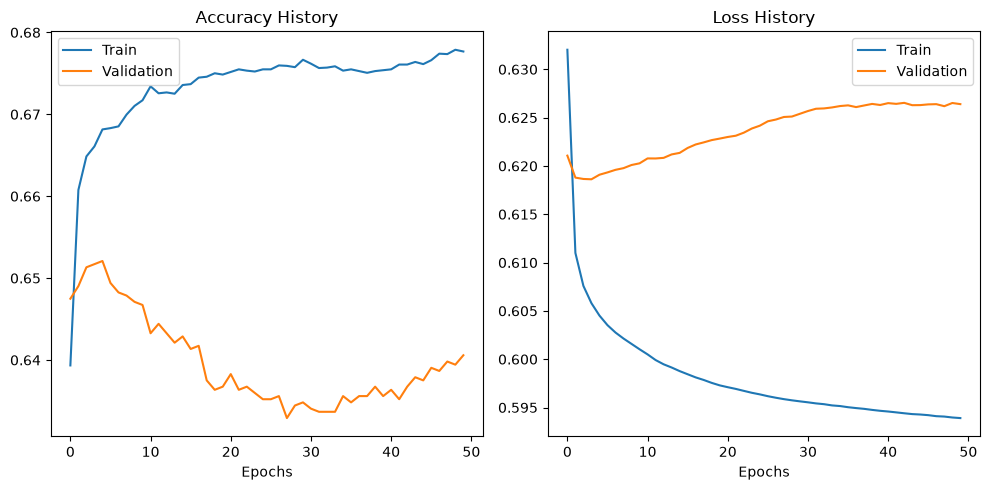

In [18]:
# plot training and validation accuracy 

%matplotlib inline 

fig, axes = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 5)
)

axes[0].plot(hist.history["accuracy"], label="Train")
axes[0].plot(hist.history["val_accuracy"], label="Validation")

axes[0].set_title("Accuracy History")
axes[0].set_xlabel("Epochs")
axes[0].legend()

axes[1].plot(hist.history["loss"], label="Train")
axes[1].plot(hist.history["val_loss"], label="Validation")

axes[1].set_title("Loss History")
axes[1].set_xlabel("Epochs")
axes[1].legend()

plt.tight_layout()
plt.show()


In [19]:
validation_loss, validation_accuracy = (
    model.evaluate(
        X_validation, 
        y_validation, 
        verbose=0
    )
)

print("Validation loss:", validation_loss)
print("Validation accuracy:", validation_accuracy)

Validation loss: 0.6263981461524963
Validation accuracy: 0.6405830383300781


In [20]:
validation_probabilities = model.predict(
    X_validation, 
    verbose=0
)

validation_probabilities = (
    validation_probabilities.reshape(-1)
)

In [21]:
validation_predictions = (
    validation_probabilities >= 0.5
).astype(int)

In [22]:
prediction_example = pd.DataFrame(
    {
        "ProbabilityPlayer1Wins": validation_probabilities[:10],
        "PredictedClass": validation_predictions[:10],
        "TrueClass": y_validation[:10]
    }
)

prediction_example

,ProbabilityPlayer1Wins,PredictedClass,TrueClass
0,0.503914,1,0
1,0.363900,0,0
2,0.548078,1,0
3,0.625012,1,1
4,0.611739,1,0
5,0.675654,1,0
6,0.845709,1,0
7,0.523905,1,1
8,0.404816,0,0
9,0.533276,1,0


In [23]:
initial_results = pd.DataFrame(
    {
        "Model": ["Initial ANN"],
        "Accuracy": [
            accuracy_score(y_validation, validation_predictions)
        ], 
        "BalancedAccuracy": [
            balanced_accuracy_score(y_validation, validation_predictions)
        ], 
        "Precision": [
            precision_score(y_validation, validation_predictions, zero_division=0)
        ], 
        "Recall": [
            recall_score(y_validation, validation_predictions, zero_division=0)
        ], 
        "F1": [
            f1_score(y_validation, validation_predictions, zero_division=0)
        ], 
        "ROC_AUC": [
            roc_auc_score(y_validation, validation_probabilities)
        ], 
        "LogLoss": [
            log_loss(y_validation, validation_probabilities)
        ]
    }
)

initial_results

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC_AUC,LogLoss
0,Initial ANN,0.640583,0.642422,0.609262,0.67958,0.642503,0.699597,0.626398


In [24]:
print("Classification Report")

print(
    classification_report(
        y_validation, 
        validation_predictions, 
        target_names=[
            "Player 2 wins", 
            "Player 1 wins"
        ], 
        zero_division=0
    )
)

Classification Report
               precision    recall  f1-score   support

Player 2 wins       0.68      0.61      0.64      1368
Player 1 wins       0.61      0.68      0.64      1239

     accuracy                           0.64      2607
    macro avg       0.64      0.64      0.64      2607
 weighted avg       0.64      0.64      0.64      2607



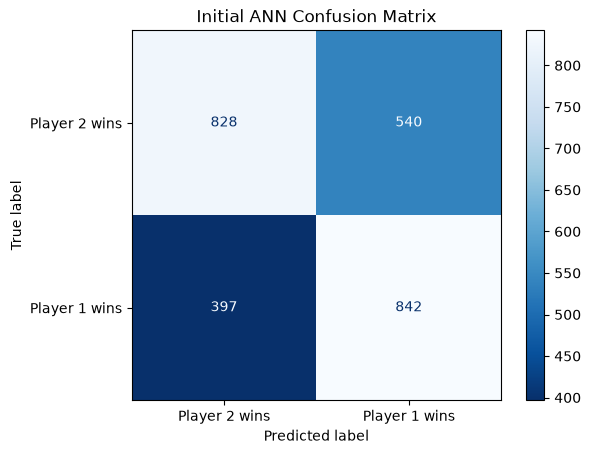

In [25]:
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    validation_predictions,
    display_labels=[
        "Player 2 wins",
        "Player 1 wins"
    ],
    values_format="d",
    cmap="Blues_r"
)

plt.title("Initial ANN Confusion Matrix")
plt.show()

The project requires parameter tuning. I keep the search small and manual, like the experiments in the lessons.

I vary:
- hidden-layer size
- number of hidden layers
- activation
- learning rate
- number of epochs

In [26]:
def build_model(
    input_features,
    hidden_layers,
    hidden_activation,
    learning_rate
):
    """
    Build and compile an Artificial Neural Network.

    input_features:
        Number of input variables received by the ANN.

    hidden_layers:
        List containing the number of neurons
        in each hidden layer.

    hidden_activation:
        Activation function used by hidden layers.

    learning_rate:
        Learning rate used by Adam.
    """
    #initialize network 
    current_model = Sequential()
    
    #input 
    current_model.add(Input(shape=(input_features,)))
    
    #hidden layer 
    # Example:
    # hidden_layers = [32, 16]
    #
    # creates two hidden layers:
    # 32 neurons -> 16 neurons.
    for number_of_neurons in hidden_layers: 
        
        current_model.add(Dense(number_of_neurons))
        current_model.add(Activation(hidden_activation))
        
    # Binary output:
    # probability that Player 1 wins.
    current_model.add(Dense(1))
    current_model.add(Activation("sigmoid"))
    
    #finalize the network 
    current_model.compile(
        optimizer=optimizers.Adam(
            learning_rate=learning_rate
        ), 
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return current_model

In [27]:
configurations = [
    {
        "name" : "ANN 8 sigmoid",
        "hidden_layers": [8], 
        "activation": "sigmoid", 
        "learning_rate": 0.01, 
        "epochs": 50
    }, 
    
    {
        "name": "ANN 16 relu",
        "hidden_layers": [16], 
        "activation": "relu", 
        "learning_rate": 0.001, 
        "epochs": 50
    },
    
    {
        "name": "ANN 32 relu", 
        "hidden_layers": [32], 
        "activation": "relu", 
        "learning_rate": 0.001, 
        "epochs": 50
    }, 
    
    {
        "name": "ANN 32-16 relu", 
        "hidden_layers": [32, 16], 
        "activation": "relu", 
        "learning_rate": 0.001, 
        "epochs": 50
    }, 
    
    {
        "name": "ANN 32-16 slow", 
        "hidden_layers": [32, 16], 
        "activation": "relu",
        "learning_rate": 0.0005, 
        "epochs": 100
    }
    
]

In [28]:
# One row will be stored for every:
# configuration × temporal fold
# With 5 configurations and 4 folds,
# we expect 20 rows.

cv_results = []

for configuration in configurations: 
    
    print("\nTesting ANN model:", configuration["name"])
    
    # Evaluate the current ANN configuration
    # on all four temporal folds.

    for fold in temporal_folds:

        fold_number = fold["Fold"]
        validation_year = fold["ValidationYear"]


        print(
            "  Fold",
            fold_number,
            "- validation year:",
            validation_year
        )
        
        #recerate current training and validation sets for the current fold

        fold_train = train_data.loc[
            train_data["Date"].dt.year < validation_year
        ].copy()
        
        fold_validation = train_data.loc[
            train_data["Date"].dt.year == validation_year
        ].copy()
        
        #learn medians, modes and one-hot encoder from the current fold_train
        (
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        ) = fit_preprocessor(
            fold_train
        )
        
        #transfrorm the current fold_train and fold_validation sets
        X_fold_train = transform_data(
            fold_train,
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        )


        X_fold_validation = transform_data(
            fold_validation,
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        )
        
         # Targets for this fold.

        y_fold_train = (
            fold_train["Player1Won"].to_numpy()
        )

        y_fold_validation = (
            fold_validation["Player1Won"].to_numpy()
        )
        
        # A NEW scaler is fitted for every temporal fold.
        # fit only on fold training,
        # never on fold validation.
        
        fold_scaler = StandardScaler()
        
        #scale only the numerical features, not the one-hot encoded categorical features
        X_fold_train[numeric_features] = (
            fold_scaler.fit_transform(
                X_fold_train[numeric_features]
            )
        )
        
        X_fold_validation[numeric_features] = (
            fold_scaler.transform(
                X_fold_validation[numeric_features]
            )
        ) 
        
        X_fold_train = X_fold_train.to_numpy(dtype=np.float32)
        X_fold_validation = X_fold_validation.to_numpy(dtype=np.float32)  
        
        #build the ANN for the current configuration
        np.random.seed(42)
        tf.random.set_seed(42)


        current_model = build_model(
            input_features=X_fold_train.shape[1],
            hidden_layers=configuration["hidden_layers"],
            hidden_activation=configuration["activation"],
            learning_rate=configuration["learning_rate"]
        )
        
        #train the ANN for the current configuration
        current_model.fit(
            x=X_fold_train,
            y=y_fold_train,
            epochs=configuration["epochs"],
            batch_size=128,
            verbose=0
        ) 
        
        #predict the current fold validation set
        current_fold_probabilities = ( current_model.predict(
                X_fold_validation,
                verbose=0
            ).reshape(-1)
        )
        
        # probability >= 0.5 -> Player 1 wins
        # probability < 0.5  -> Player 2 wins
        current_fold_predictions = (
            current_fold_probabilities >= 0.5
        ).astype(int)
        
        #use common evaluation function to calculate metrics for the current fold
        current_fold_results = evaluate_model(
            y_true=y_fold_validation,
            y_pred=current_fold_predictions,
            model_name=configuration["name"],
            y_probability=current_fold_probabilities
        )
        
        #store the current fold results into dictionary
        current_fold_results = ( current_fold_results.iloc[0].to_dict())
        
        #add info to identify fold
        current_fold_results["Fold"] = fold_number
        current_fold_results["ValidationYear"] = validation_year
        
        #store the current fold results into the list of all results
        cv_results.append(current_fold_results)
        


Testing ANN model: ANN 8 sigmoid
  Fold 1 - validation year: 2019
  Fold 2 - validation year: 2020
  Fold 3 - validation year: 2021
  Fold 4 - validation year: 2022

Testing ANN model: ANN 16 relu
  Fold 1 - validation year: 2019
  Fold 2 - validation year: 2020
  Fold 3 - validation year: 2021
  Fold 4 - validation year: 2022

Testing ANN model: ANN 32 relu
  Fold 1 - validation year: 2019
  Fold 2 - validation year: 2020
  Fold 3 - validation year: 2021
  Fold 4 - validation year: 2022

Testing ANN model: ANN 32-16 relu
  Fold 1 - validation year: 2019
  Fold 2 - validation year: 2020
  Fold 3 - validation year: 2021
  Fold 4 - validation year: 2022

Testing ANN model: ANN 32-16 slow
  Fold 1 - validation year: 2019
  Fold 2 - validation year: 2020
  Fold 3 - validation year: 2021
  Fold 4 - validation year: 2022


In [29]:
ann_cv_results = pd.DataFrame(cv_results)

ann_cv_results 

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC-AUC,LogLoss,Fold,ValidationYear
0,ANN 8 sigmoid,0.617942,0.617665,0.621993,0.584814,0.602831,0.674940,0.643685,1,2019
1,ANN 8 sigmoid,0.644192,0.648083,0.702213,0.546166,0.614437,0.704691,0.634306,2,2020
2,ANN 8 sigmoid,0.634888,0.633420,0.625455,0.596704,0.610741,0.690628,0.632994,3,2021
3,ANN 8 sigmoid,0.643615,0.643623,0.640220,0.644778,0.642491,0.704327,0.622200,4,2022
4,ANN 16 relu,0.613536,0.613472,0.611247,0.605816,0.608519,0.672645,0.642509,1,2019
5,ANN 16 relu,0.650690,0.652044,0.680484,0.616588,0.646962,0.709935,0.623419,2,2020
6,ANN 16 relu,0.629475,0.629516,0.610411,0.630529,0.620307,0.686064,0.634558,3,2021
7,ANN 16 relu,0.647151,0.647209,0.641641,0.655854,0.648670,0.704359,0.625590,4,2022
8,ANN 32 relu,0.613536,0.613297,0.616170,0.584814,0.600083,0.663784,0.649688,1,2019
9,ANN 32 relu,0.646629,0.649250,0.689591,0.580595,0.630416,0.711363,0.626834,2,2020


In [30]:
#check that the number of experiments is correct
print("Number of experiments:", ann_cv_results.shape[0])
assert(len(ann_cv_results) == len(configurations) * len(temporal_folds))

Number of experiments: 20


#CALCULATE MEAN OF THE 4 FOLDS#
For each ANN configuration, calculate mean and sd. 

In [41]:
ann_cv_summary = ann_cv_results.groupby("Model", as_index=False).agg(
        MeanAccuracy = ("Accuracy", "mean"),
        StdAccuracy = ("Accuracy", "std"),
        MeanBalancedAccuracy = ("BalancedAccuracy", "mean"),
        MeanF1Score = ("F1", "mean"),
        MeanROC_AUC = ("ROC-AUC", "mean"),
        MeanLogLoss = ("LogLoss", "mean")
)

In [42]:
#prefer configuration with highest avarage temporal-CV accuracy
#ROC-AUC used as tie-breaker
ann_cv_summary = ann_cv_summary.sort_values(
    by=["MeanAccuracy", "MeanROC_AUC"],
    ascending=[False, False]
).reset_index(drop=True)

ann_cv_summary

,Model,MeanAccuracy,StdAccuracy,MeanBalancedAccuracy,MeanF1Score,MeanROC_AUC,MeanLogLoss
0,ANN 32 relu,0.637060,0.016641,0.637483,0.625306,0.694979,0.631844
1,ANN 16 relu,0.635213,0.017174,0.635560,0.631115,0.693251,0.631519
2,ANN 8 sigmoid,0.635159,0.012242,0.635698,0.617625,0.693646,0.633296
3,ANN 32-16 slow,0.632447,0.015942,0.633147,0.628042,0.682977,0.651510
4,ANN 32-16 relu,0.632058,0.007869,0.632736,0.614634,0.684532,0.648953


In [43]:
#store the name of the configuartion with best mean temporal-CV accuracy
best_model_name = (ann_cv_summary.iloc[0]["Model"])
print("Selected ANN from temporal CV:", best_model_name)

Selected ANN from temporal CV: ANN 32 relu


In [44]:
#store and print the complete parameter dictionary of the best model

best_configuration = next(
    configuration
    for configuration in configurations 
    if configuration["name"]== best_model_name
)

best_configuration

{'name': 'ANN 32 relu',
 'hidden_layers': [32],
 'activation': 'relu',
 'learning_rate': 0.001,
 'epochs': 50}

Create a new ANN from scratch. Do not use fold models

In [45]:
np.random.seed(42)
tf.random.set_seed(42)

#build a new model using configuartion chose by temporal CV 
best_model = build_model(
    input_features=X_train.shape[1],
    hidden_layers=best_configuration["hidden_layers"],
    hidden_activation= best_configuration["activation"],
    learning_rate=best_configuration["learning_rate"]
)


In [47]:
#train the selected configuration on all training data: 2015-2022
# 2023=validation set

best_history = best_model.fit(
    x=X_train,
    y=y_train,
    epochs=best_configuration["epochs"],
    validation_data=(X_validation, y_validation),
    verbose=1
)

Epoch 1/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6453 - loss: 0.6262 - val_accuracy: 0.6352 - val_loss: 0.6240
Epoch 2/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6606 - loss: 0.6096 - val_accuracy: 0.6371 - val_loss: 0.6218
Epoch 3/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6641 - loss: 0.6064 - val_accuracy: 0.6352 - val_loss: 0.6215
Epoch 4/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6666 - loss: 0.6044 - val_accuracy: 0.6318 - val_loss: 0.6216
Epoch 5/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6674 - loss: 0.6029 - val_accuracy: 0.6364 - val_loss: 0.6219
Epoch 6/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6683 - loss: 0.6018 - val_accuracy: 0.6337 - val_loss: 0.6224
Epoch 7/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6693 - loss: 0.6008 - val_accuracy: 0.6321 - val_loss: 0.6227
Epoch 8/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6699 - loss: 0.6000 - val_accuracy: 0.

In [ ]:
best_validation_probabilities = (
    best_model.predict(
        X_validation, 
        verbose=0
    ).reshape(-1)
)

best_validation_predictions = (
    best_validation_probabilities >= 0.5 
).astype(int)



               precision    recall  f1-score   support

Player 2 wins       0.65      0.59      0.62      1368
Player 1 wins       0.59      0.66      0.62      1239

     accuracy                           0.62      2607
    macro avg       0.62      0.62      0.62      2607
 weighted avg       0.63      0.62      0.62      2607



In [50]:
#evaluate ann selected on external 2023 validation set
best_ann_results=evaluate_model(
    y_true=y_validation,
    y_pred=validation_predictions,
    y_probability=best_validation_probabilities,
    model_name=best_model_name
)

best_ann_results

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC-AUC,LogLoss
0,ANN 32 relu,0.640583,0.642422,0.609262,0.67958,0.642503,0.688762,0.634708


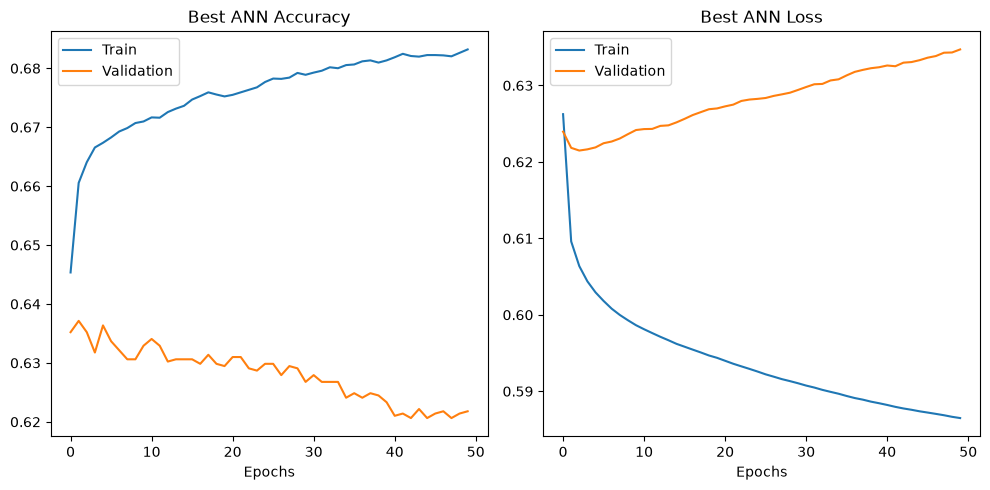

In [51]:
fig, axes = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 5)
)

axes[0].plot(best_history.history["accuracy"], label="Train")
axes[0].plot(best_history.history["val_accuracy"], label="Validation")

axes[0].set_title("Best ANN Accuracy")
axes[0].set_xlabel("Epochs")
axes[0].legend()

axes[1].plot(best_history.history["loss"], label="Train")
axes[1].plot(best_history.history["val_loss"], label="Validation")

axes[1].set_title("Best ANN Loss")
axes[1].set_xlabel("Epochs")
axes[1].legend()

plt.tight_layout()
plt.show()

In [52]:
## compare with the baseline 
baseline_file = (PROCESSED_DATA_DIR / "validation_baseline.csv")
baseline_results = pd.read_csv(baseline_file)

baseline_results = pd.read_csv(baseline_file)

# combine baseline results and ANN result
comparison_results = pd.concat(
    [
        baseline_results[
            [
                "Model",
                "Accuracy",
                "BalancedAccuracy",
                "Precision",
                "Recall",
                "F1"
            ]
        ],
        
        best_ann_results[
            [
                "Model",
                "Accuracy",
                "BalancedAccuracy",
                "Precision",
                "Recall",
                "F1"
            ]
        ]
    ],
    ignore_index=True
)

comparison_results = (
    comparison_results
    .sort_values(
        by="Accuracy", ascending=False
    ).reset_index(drop=True)
)

comparison_results


,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1
0,ANN 32 relu,0.640583,0.642422,0.609262,0.679580,0.642503
1,Better-ranked player,0.640199,0.640648,0.614973,0.649718,0.631868
2,More ranking points,0.626007,0.626592,0.600152,0.638418,0.618694
3,Higher previous win rate,0.607979,0.608424,0.582635,0.617433,0.599530
4,Better recent win rate,0.549674,0.557169,0.519219,0.708636,0.599317
5,Majority class,0.524741,0.500000,0.000000,0.000000,0.000000


In [53]:
# create an analysis table
ann_validation_analysis = (
    validation_data [
        [   
            "MatchID",
            "Date",
            "Tournament",
            "Surface",
            "Round",
            "Player1",
            "Player2",
            "Player1Rank",
            "Player2Rank",
            "RankDifference",
            "WinRateDifference",
            "Recent5WinRateDifference",
            "SurfaceWinRateDifference",
            "Player1Won"
        ]
    ].copy()
)

In [54]:
# add the ann results
ann_validation_analysis[
    "ANNProbability"
] = best_validation_probabilities

ann_validation_analysis[
    "ANNPrediction"
] = best_validation_predictions

ann_validation_analysis[
    "Correct"
] = (
    ann_validation_analysis[
        "ANNPrediction"
    ] == ann_validation_analysis[
        "Player1Won"
    ]
)

#calculate prediction confidence
ann_validation_analysis[
    "Confidence"
] = np.maximum(
    ann_validation_analysis[
        "ANNProbability"
    ],
    1 - ann_validation_analysis["ANNProbability"]
)

#display the ten most confident errors 
most_confident_errors = (
    ann_validation_analysis.loc[
        ann_validation_analysis[
            "Correct"
        ] == False
    ].sort_values(
        by="Confidence", ascending=False
    )
)

most_confident_errors.head(10)


,MatchID,Date,Tournament,Surface,Round,Player1,Player2,Player1Rank,Player2Rank,RankDifference,WinRateDifference,Recent5WinRateDifference,SurfaceWinRateDifference,Player1Won,ANNProbability,ANNPrediction,Correct,Confidence
19137,19137,2023-02-14,Delray Beach Open,Hard,1st Round,Sock J.,Pecotic M.,143.0,784.0,641.0,0.073991,-0.1,0.087500,0,0.990440,1,False,0.990440
19935,19935,2023-05-15,Internazionali BNL d'Italia,Clay,3rd Round,Alcaraz C.,Marozsan F.,2.0,135.0,133.0,0.031690,0.0,0.073529,0,0.942250,1,False,0.942250
19753,19753,2023-04-21,Srpska Open,Clay,Quarterfinals,Djokovic N.,Lajovic D.,1.0,70.0,69.0,0.433021,0.0,0.311874,0,0.927908,1,False,0.927908
20900,20900,2023-08-30,US Open,Hard,2nd Round,Tsitsipas S.,Stricker D.,7.0,128.0,121.0,0.149212,0.0,0.076877,0,0.924207,1,False,0.924207
19001,19001,2023-01-19,Australian Open,Hard,2nd Round,Zverev A.,Mmoh M.,13.0,107.0,94.0,0.374317,0.8,0.335272,0,0.922039,1,False,0.922039
19664,19664,2023-04-13,Monte Carlo Masters,Clay,3rd Round,Struff J.L.,Ruud C.,100.0,4.0,-96.0,-0.192799,-0.4,-0.266544,1,0.099567,0,False,0.900433
20764,20764,2023-08-16,Western & Southern Financial Group Masters,Hard,2nd Round,Lajovic D.,Sinner J.,66.0,6.0,-60.0,-0.260979,-0.4,-0.331323,1,0.101963,0,False,0.898037
19013,19013,2023-01-20,Australian Open,Hard,3rd Round,Norrie C.,Lehecka J.,12.0,71.0,59.0,0.187045,0.2,0.122004,0,0.893758,1,False,0.893758
19964,19964,2023-05-22,Geneva Open,Clay,1st Round,Mannarino A.,Krajinovic F.,47.0,917.0,870.0,-0.006511,0.4,-0.210606,1,0.108101,0,False,0.891899
19278,19278,2023-02-26,Rio Open,Clay,The Final,Alcaraz C.,Norrie C.,2.0,13.0,11.0,0.162553,0.2,0.175000,0,0.883218,1,False,0.883218


In [57]:
# create the folder to save the results 
RESULTS_DIR = Path("../results")
MODELS_DIR = Path("../models")

RESULTS_DIR.mkdir(
    parents = True,
    exist_ok=True
)

MODELS_DIR.mkdir(
    parents=True, 
    exist_ok=True
)

ann_cv_results.to_csv(
    RESULTS_DIR / "ann_cv_fold_results.csv",
    index=False
)

ann_cv_summary.to_csv(
    RESULTS_DIR / "ann_cv_summary.csv",
    index=False
)

ann_validation_analysis.to_csv(
    RESULTS_DIR / "ann_validation_predictions.csv",
    index=False
)

best_model.save(
    MODELS_DIR / "best_ann_validation.keras"
)

In [58]:
# final tuning summary 
print("ANN temporal-cv tuning:")

print(ann_cv_summary)


ANN temporal-cv tuning:
            Model  MeanAccuracy  StdAccuracy  MeanBalancedAccuracy  \
0     ANN 32 relu      0.637060     0.016641              0.637483   
1     ANN 16 relu      0.635213     0.017174              0.635560   
2   ANN 8 sigmoid      0.635159     0.012242              0.635698   
3  ANN 32-16 slow      0.632447     0.015942              0.633147   
4  ANN 32-16 relu      0.632058     0.007869              0.632736   

   MeanF1Score  MeanROC_AUC  MeanLogLoss  
0     0.625306     0.694979     0.631844  
1     0.631115     0.693251     0.631519  
2     0.617625     0.693646     0.633296  
3     0.628042     0.682977     0.651510  
4     0.614634     0.684532     0.648953  


In [59]:
print(
    "Selected ANN:",
    best_model_name
)

print("\nExternal 2023 validation:")
print(best_ann_results)

print("\nANN and baseline comparison:")

print(
    comparison_results
)

Selected ANN: ANN 32 relu

External 2023 validation:
         Model  Accuracy  BalancedAccuracy  Precision   Recall        F1  \
0  ANN 32 relu  0.640583          0.642422   0.609262  0.67958  0.642503   

    ROC-AUC   LogLoss  
0  0.688762  0.634708  

ANN and baseline comparison:
                      Model  Accuracy  BalancedAccuracy  Precision    Recall  \
0               ANN 32 relu  0.640583          0.642422   0.609262  0.679580   
1      Better-ranked player  0.640199          0.640648   0.614973  0.649718   
2       More ranking points  0.626007          0.626592   0.600152  0.638418   
3  Higher previous win rate  0.607979          0.608424   0.582635  0.617433   
4    Better recent win rate  0.549674          0.557169   0.519219  0.708636   
5            Majority class  0.524741          0.500000   0.000000  0.000000   

         F1  
0  0.642503  
1  0.631868  
2  0.618694  
3  0.599530  
4  0.599317  
5  0.000000  


In [60]:
print(
    most_confident_errors[
        [
            "Date",
            "Player1",
            "Player2",
            "Player1Won",
            "ANNPrediction",
            "ANNProbability",
            "Confidence"
        ]
    ].head(10)
)

            Date       Player1        Player2  Player1Won  ANNPrediction  \
19137 2023-02-14       Sock J.     Pecotic M.           0              1   
19935 2023-05-15    Alcaraz C.    Marozsan F.           0              1   
19753 2023-04-21   Djokovic N.     Lajovic D.           0              1   
20900 2023-08-30  Tsitsipas S.    Stricker D.           0              1   
19001 2023-01-19     Zverev A.        Mmoh M.           0              1   
19664 2023-04-13   Struff J.L.        Ruud C.           1              0   
20764 2023-08-16    Lajovic D.      Sinner J.           1              0   
19013 2023-01-20     Norrie C.     Lehecka J.           0              1   
19964 2023-05-22  Mannarino A.  Krajinovic F.           1              0   
19278 2023-02-26    Alcaraz C.      Norrie C.           0              1   

       ANNProbability  Confidence  
19137        0.990440    0.990440  
19935        0.942250    0.942250  
19753        0.927908    0.927908  
20900        0.9242